# Classification Metrics

A comprehensive guide to evaluating classification models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../datasets/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [21]:
# Drop non-predictive columns
df = df.drop(columns=["id", "dataset"], errors="ignore")

# Fill missing values: median for numeric, mode for categorical
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode categorical columns
df = pd.get_dummies(df, drop_first=True)

df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150.0,False,2.3,0.0,0,True,False,False,True,False,False,False,False,False,False
1,67,160.0,286.0,False,108.0,True,1.5,3.0,2,True,False,False,False,False,False,True,False,True,False
2,67,120.0,229.0,False,129.0,True,2.6,2.0,1,True,False,False,False,False,False,True,False,False,True
3,37,130.0,250.0,False,187.0,False,3.5,0.0,0,True,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0.0,0,False,True,False,False,False,False,False,True,True,False


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train , x_test , y_train , y_test = train_test_split(df.drop("num",axis=1) , df["num"] , test_size=0.2 , random_state=42)

x_train.shape , x_test.shape , y_train.shape , y_test.shape

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
from sklearn.linear_model import LogisticRegression     # despite the name, it is a classification model
from sklearn.tree import DecisionTreeClassifier

In [24]:
classifier1 = LogisticRegression(max_iter=1000)
classifier2 = DecisionTreeClassifier()

In [25]:
classifier1.fit(x_train , y_train )
classifier2.fit(x_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [26]:
y_pred1 = classifier1.predict(x_test)
y_pred2 = classifier2.predict(x_test)

## **Accuracy**

Accuracy measures the proportion of correct predictions out of all predictions made.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

| Symbol | Meaning |
|--------|---------|
| TP | True Positives — correctly predicted positive |
| TN | True Negatives — correctly predicted negative |
| FP | False Positives — predicted positive, actually negative *(Type I Error)* |
| FN | False Negatives — predicted negative, actually positive *(Type II Error)* |

### The Accuracy Trap — A Real-World Example

Imagine an airport security model trained to detect terrorists among passengers:

| | Value |
|--|--|
| Total passengers | 1,00,000 |
| Terrorists | 1 |
| Non-terrorists | 99,999 |

A model that **always predicts "Not a Terrorist"** would get:

$$
\text{Accuracy} = \frac{0 + 99999}{1,00,000} = 99.999\%
$$

Looks great on paper — but it **missed the only actual terrorist (FN = 1, Type II Error)**. This is a catastrophic failure that accuracy completely hides.

### Type I vs Type II Errors

| | Type I Error (FP) | Type II Error (FN) |
|--|--|--|
| **What happened** | Predicted Positive, was actually Negative | Predicted Negative, was actually Positive |
| **Also known as** | False Alarm | Miss |
| **Airport example** | Flagging an innocent passenger as terrorist | Missing an actual terrorist |
| **Medical example** | Healthy patient diagnosed with disease | Sick patient told they are healthy |

> In most high-stakes scenarios, **Type II errors (FN) are more dangerous** — missing a real threat is worse than a false alarm.

### Limitations

- **Misleading on imbalanced data** — majority-class prediction inflates accuracy while the minority class is entirely ignored.
- **Hides error types** — doesn't distinguish between Type I (FP) and Type II (FN) errors, which carry very different real-world costs.

> **Takeaway:** Accuracy is a useful first glance, but always complement it with **Precision**, **Recall**, and **F1-score** — especially on imbalanced datasets.

In [27]:
from sklearn.metrics import accuracy_score , confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Regression Accuracy: 0.532608695652174
Decision Tree Accuracy: 0.5163043478260869


## **Confusion Matrix**

A confusion matrix breaks down predictions into four categories, revealing **what kind of errors** a model makes — not just how many.

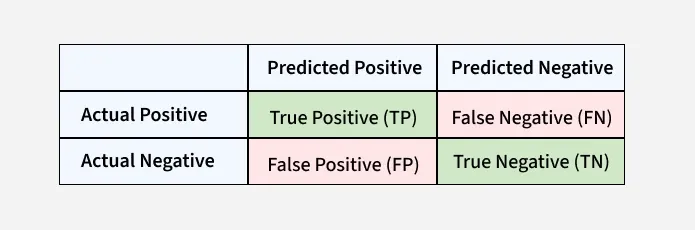

> **Reading the names:** First word = was the prediction **correct**? Second word = what did the model **predict**?
> e.g. *False Positive* → prediction was wrong (**False**), and it predicted **Positive**.

### Multi-class & Imbalanced Data

- For **n classes**, the matrix is **n × n**: entry *(i, j)* = how many times class *i* was predicted as class *j*; diagonal = correct predictions.
- On **imbalanced datasets**, a model predicting only the majority class scores high accuracy, but the matrix exposes it — all minority class samples land in FN, with zero TP.

In [29]:
from sklearn.metrics import confusion_matrix

print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))

Logistic Regression Confusion Matrix:
 [[63 12  0  0  0]
 [21 30  0  3  0]
 [ 2 17  2  4  0]
 [ 5 10  6  3  2]
 [ 0  1  1  2  0]]
Decision Tree Confusion Matrix:
 [[59 11  2  3  0]
 [16 22  9  6  1]
 [ 4  6 11  4  0]
 [ 5 12  4  3  2]
 [ 0  1  1  2  0]]


In [33]:
# visualize using dataframe for better readability

print("Logistic Regression Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test, y_pred1), columns=list(range(0,5)))

Logistic Regression Confusion Matrix



,0,1,2,3,4
0,63,12,0,0,0
1,21,30,0,3,0
2,2,17,2,4,0
3,5,10,6,3,2
4,0,1,1,2,0


## **Precision**